# Building a basic model to predict players' FPL performance directly

## Context

The aim of this project is to design automated Fantasy Premier League team selection and transfer strategies that perform competitively, which requires us to predict player performance with some accuracy. There are two main approaches we can take to predict player performance:

1. Direct prediction - predict FPL points directly 
2. Decomposed prediction - predict the underlying events that contribute to points, then convert to points

Option 2 has the potential to be more accurate because FPL points are a result of many different events (see supporting material) and a single model may not be able to capture these complex interations, whereas separate models to predict the underlying events (like a model to predict goals, one to predict clean sheets, etc.) may be more accurate and more interpretable. **However, because of this complexity, the initial focus will be on building a model that predicts points directly.**

## Imports and configs

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, r2_score
import sys
from scipy.stats import spearmanr
from pyprojroot import here
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.options.mode.chained_assignment = None

sys.path.append(str(here()))

from fpl_team_optimiser.pull_data import pull_data


/Users/jamesmartin/Code Repositories/personal/fpl-team-optimiser/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Pull data

In [2]:
pull_data(force=False) # set force to True to override the existing data and pull new FPL data
DATA_PATH = "../data/{}"

Data folder already populated, skipping download.


## Data processing

In [3]:
# read in and combine all gameweek data for all seasons

seasons = ['2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
season_gws_list = []
POS_MAP = {
    1: 'GK',
    2: 'DEF',
    3: 'MID',
    4: 'FWD',
    5: 'AM'
}

for season in seasons:
    season_data = pd.read_csv(DATA_PATH.format(season) + "/gws/merged_gw.csv", encoding='iso-8859-1', on_bad_lines='skip')
    if season in ['2016-17', '2017-18', '2018-19', '2019-20']:
        # player position is encoded in players_raw.csv under element_type
        players_data = pd.read_csv(DATA_PATH.format(season) + "/players_raw.csv", encoding='iso-8859-1')[['id', 'element_type', 'team', 'squad_number']]
        season_data = season_data.merge(players_data, left_on='element', right_on='id', how='left')
        season_data['position'] = season_data['element_type'].map(POS_MAP)
        season_data.drop(columns=['element_type'], inplace=True)
    season_data['season'] = season
    season_gws_list.append(season_data)

all_season_gws_df = pd.concat(season_gws_list)
all_season_gws_df['position'] = all_season_gws_df['position'].astype('category')
all_season_gws_df

,name,assists,attempted_passes,big_chances_created,big_chances_missed,bonus,bps,clean_sheets,clearances_blocks_interceptions,completed_passes,creativity,dribbles,ea_index,element,errors_leading_to_goal,errors_leading_to_goal_attempt,fixture,fouls,goals_conceded,goals_scored,ict_index,id_x,influence,key_passes,kickoff_time,kickoff_time_formatted,loaned_in,loaned_out,minutes,offside,open_play_crosses,opponent_team,own_goals,penalties_conceded,penalties_missed,penalties_saved,recoveries,red_cards,round,saves,selected,tackled,tackles,target_missed,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,winning_goals,yellow_cards,GW,id_y,team,squad_number,position,season,id,xP,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,starts,modified
0,Aaron_Cresswell,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,454,0.0,0.0,10,0.0,0,0,0.0,454.0,0.0,0.0,2016-08-15T19:00:00Z,15 Aug 20:00,0.0,0.0,0,0.0,0.0,4,0,0.0,0,0,0.0,0,1,0,14023,0.0,0.0,0.0,1.0,2.0,0.0,0,0,0,0,55,False,0.0,0,1,454.0,20,3.0,DEF,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Aaron_Lennon,0,3.0,0.0,0.0,0,6,0,1.0,2.0,0.3,0.0,0.0,142,0.0,0.0,3,0.0,0,0,0.9,142.0,8.2,0.0,2016-08-13T14:00:00Z,13 Aug 15:00,0.0,0.0,15,0.0,0.0,17,0,0.0,0,0,1.0,0,1,0,13918,1.0,2.0,0.0,1.0,1.0,0.0,1,0,0,0,60,True,0.0,0,1,142.0,6,12.0,MID,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Aaron_Ramsey,0,26.0,0.0,0.0,0,5,0,2.0,22.0,4.9,1.0,0.0,16,0.0,0.0,8,0.0,3,0,3.0,16.0,2.2,0.0,2016-08-14T15:00:00Z,14 Aug 16:00,0.0,0.0,60,0.0,0.0,9,0,0.0,0,0,2.0,0,1,0,163170,2.0,0.0,1.0,4.0,3.0,23.0,2,0,0,0,80,True,0.0,0,1,16.0,1,8.0,MID,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Abdoulaye_Doucouré,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,482,0.0,0.0,7,0.0,0,0,0.0,482.0,0.0,0.0,2016-08-13T14:00:00Z,13 Aug 15:00,0.0,0.0,0,0.0,0.0,13,0,0.0,0,0,0.0,0,1,0,1051,0.0,0.0,0.0,1.0,1.0,0.0,0,0,0,0,50,False,0.0,0,1,482.0,18,16.0,MID,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Abdul Rahman_Baba,0,0.0,0.0,0.0,0,0,0,0.0,0.0,0.0,0.0,0.0,80,0.0,0.0,10,0.0,0,0,0.0,80.0,0.0,0.0,2016-08-15T19:00:00Z,15 Aug 20:00,0.0,0.0,0,0.0,0.0,20,0,0.0,0,0,0.0,0,1,0,1243,0.0,0.0,0.0,1.0,2.0,0.0,0,0,0,0,55,True,0.0,0,1,80.0,4,6.0,DEF,2016-17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14173,Giovani Lo Celso,0,NaN,NaN,NaN,0,0,0,NaN,NaN,0.0,NaN,NaN,493,NaN,NaN,201,NaN,0,0,0.0,NaN,0.0,NaN,2025-01-15T20:00:00Z,NaN,NaN,NaN,0,NaN,NaN,1,0,NaN,0,0,NaN,0,21,0,3136,NaN,NaN,NaN,1.0,2.0,0.0,0,-24,0,24,49,False,NaN,0,21,NaN,Spurs,NaN,MID,2024-25,NaN,0.0,0.00,0.00,0.0,0.00,0.0,False
14174,Tawanda Chirewa,0,NaN,NaN,NaN,0,0,0,NaN,NaN,0.0,NaN,NaN,538,NaN,NaN,210,NaN,0,0,0.0,NaN,0.0,NaN,2025-01-15T19:30:00Z,NaN,NaN,NaN,0,NaN,NaN,15,0,NaN,0,0,NaN,0,21,0,2746,NaN,NaN,NaN,0.0,3.0,0.0,0,-38,0,38,45,False,NaN,0,21,NaN,Wolves,NaN,MID,2024-25,NaN,0.0,0.00,0.00,0.0,0.00,0.0,False
14175,Cameron Humphreys,0,NaN,NaN,NaN,0,0,0,NaN,NaN,0.0,NaN,NaN,273,NaN,NaN,204,NaN,0,0,0.0,NaN,0.0,NaN,2025-01-16T19:30:00Z,NaN,NaN,NaN,0,NaN,NaN,5,0,NaN,0,0,NaN,0,21,0,1373,NaN,NaN,NaN,2.0,0.0,0.0,0,-23,0,23,45,True,NaN,0,21,NaN,Ipswich,NaN,MID,2024-25,NaN,0.0,0.00,0.00,0.0,0.00,0.0,False
14176,Ashley Young,0,NaN,NaN,NaN,0,9,0,NaN,NaN,15.7,NaN,NaN,238,NaN,NaN,203,NaN,1,0,2.6,NaN,10.6,NaN,2025-01-15T19:30:00Z,NaN,NaN,NaN,82,NaN,NaN,2,0,NaN,0,0,NaN,0,21,0,370376,NaN,NaN,NaN,1.0,0.0,0.0,2,-19765,14251,34016,47,True,NaN,0,21,NaN,Everton,NaN,DEF,2024-25,NaN,2.0,0.05,0.05,0.0,1.21,1.0,False


In [4]:
# for now, lets just use features present across all seasons to maximise our training set
features = pd.DataFrame()
for season in seasons:
    features = pd.concat([features, all_season_gws_df[all_season_gws_df['season'] == season].notnull().any().to_frame(name=season).T])

all_true_cols = features.columns[features.all()]
all_season_gws_df = all_season_gws_df[all_true_cols]
all_true_cols


Index(['name', 'assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
       'element', 'fixture', 'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'kickoff_time', 'minutes', 'opponent_team', 'own_goals',
       'penalties_missed', 'penalties_saved', 'red_cards', 'round', 'saves',
       'selected', 'team_a_score', 'team_h_score', 'threat', 'total_points',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'was_home', 'yellow_cards', 'GW', 'team', 'position', 'season'],
      dtype='object')

## Exploration

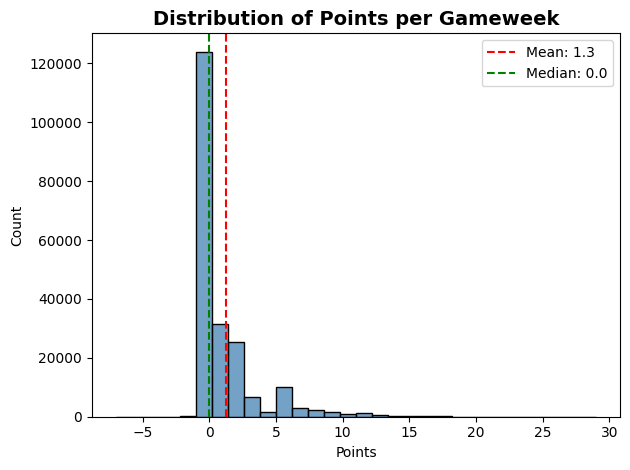

In [5]:
sns.histplot(all_season_gws_df['total_points'], bins=30, color='steelblue', edgecolor='black')
plt.axvline(all_season_gws_df['total_points'].mean(), color='red', linestyle='--', label=f"Mean: {all_season_gws_df['total_points'].mean():.1f}")
plt.axvline(all_season_gws_df['total_points'].median(), color='green', linestyle='--', label=f"Median: {all_season_gws_df['total_points'].median():.1f}")
plt.title('Distribution of Points per Gameweek', fontsize=14, fontweight='bold')
plt.xlabel('Points')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

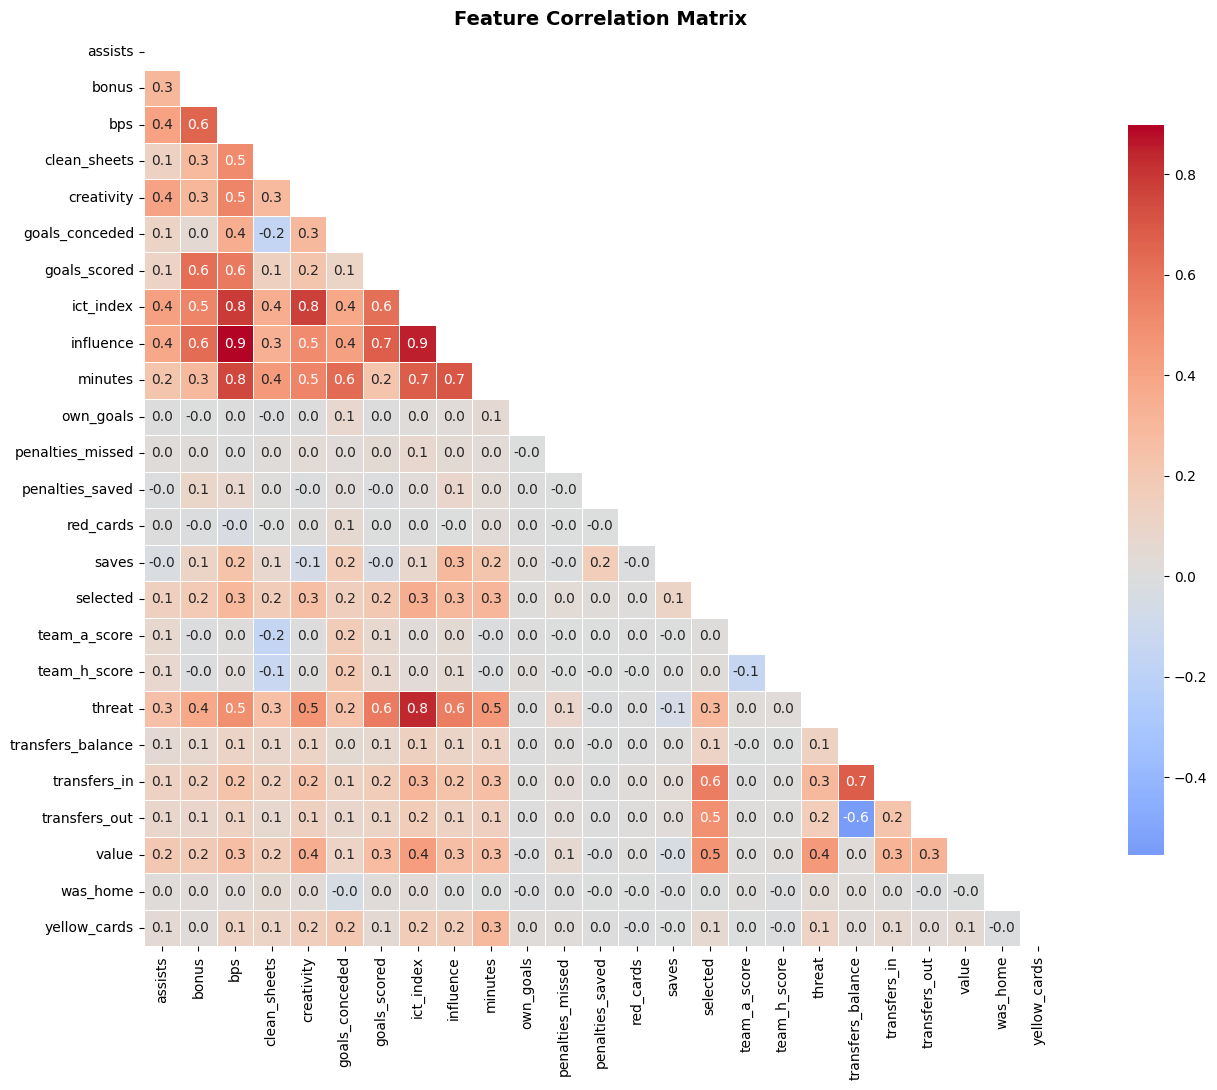

In [6]:
potential_features = ['assists', 'bonus', 'bps', 'clean_sheets', 'creativity',
       'goals_conceded', 'goals_scored', 'ict_index',
       'influence', 'minutes', 'own_goals',
       'penalties_missed', 'penalties_saved', 'red_cards', 'saves',
       'selected', 'team_a_score', 'team_h_score', 'threat',
       'transfers_balance', 'transfers_in', 'transfers_out', 'value',
       'was_home', 'yellow_cards'
]

corr = all_season_gws_df[potential_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(15, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Feature selection


In [7]:
GAME_WINDOW_RANGES = [3, 5, 10]

In [8]:
# 1. Derive Points per 90 before gameweek as an estimate the player's overall quality, independent of their form.

all_season_gws_df['kickoff_time'] = pd.to_datetime(all_season_gws_df['kickoff_time'])
all_season_gws_df = all_season_gws_df.sort_values(by=['name', 'kickoff_time'])

# cumulative points and minutes
all_season_gws_df['cumulative_points_before_gw'] = all_season_gws_df.groupby('name')['total_points'].cumsum() - all_season_gws_df['total_points']
all_season_gws_df['cumulative_minutes_before_gw'] = all_season_gws_df.groupby('name')['minutes'].cumsum() - all_season_gws_df['minutes']

all_season_gws_df['points_per_90_before_gw'] = all_season_gws_df['cumulative_points_before_gw'] / all_season_gws_df['cumulative_minutes_before_gw'] * 90
all_season_gws_df.loc[all_season_gws_df['cumulative_minutes_before_gw'] == 0, 'points_per_90_before_gw'] = 0

In [9]:
# 2. Calculate rolling average of minutes played 

all_season_gws_df = all_season_gws_df.sort_values(['name', 'season', 'kickoff_time'])

for n in GAME_WINDOW_RANGES: 
    all_season_gws_df[f'avg_minutes_last_{n}_games'] = (
    all_season_gws_df
    .groupby(['name', 'season'])['minutes']
    .transform(lambda s: s.shift(1).rolling(window=n, min_periods=1).mean())
)

In [10]:
# 3. proxy "currently unavailable" by looking at consecutive zero minutes gws
all_season_gws_df['is_zero_minutes'] = (all_season_gws_df['minutes'] == 0).astype(int)

# Run-length of consecutive zero-minute gameweeks up to (not including) this row
def consecutive_zeros_before(group):
    shifted = group['is_zero_minutes'].shift(1).fillna(0)
    # reset counter whenever a non-zero gameweek breaks the streak
    streak = shifted.groupby((shifted == 0).cumsum()).cumsum()
    return streak

all_season_gws_df['consecutive_zero_gws_before'] = (
    all_season_gws_df.groupby(['name', 'season'], group_keys=False).apply(consecutive_zeros_before)
)

/var/folders/vs/935yxs7529d032gjxpn70cv80000gn/T/ipykernel_47844/3491465354.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  all_season_gws_df.groupby(['name', 'season'], group_keys=False).apply(consecutive_zeros_before)


In [11]:
# 4. proxy definite suspensions true or false by looking for a red card in the previous gameweek WITHIN the season
all_season_gws_df['definite_suspension'] = all_season_gws_df.groupby(['season', 'name'])['red_cards'].shift(1).fillna(0).astype(int)

In [12]:
# # 5. proxy possible suspensions true or false by looking for a red card in the previous 5 gameweeks WITHIN the season
# all_season_gws_df['possible_suspension'] = all_season_gws_df.groupby(['season', 'name'])['red_cards'].rolling(5, min_periods=1).sum().shift(1).fillna(0).astype(int)
# all_season_gws_df

In [13]:
# 6. proxy fixture difficullty by looking at goals scored and conceded by the opponent team and the players team

# 6a. build a team matches df with goals scored and conceded for each team in each fixture, then calculate rolling averages of goals scored and conceded for each team over the game window range
# this can then be used both for the player's team's stats and the opponent team
team_matches = (
    all_season_gws_df.drop_duplicates(subset=["team", "fixture", "season"])
    [["team", "opponent_team", "fixture", "season", "round",
        "kickoff_time", "was_home", "team_h_score", "team_a_score"]]
    .copy()
)

team_matches["goals_scored"] = np.where(
    team_matches["was_home"], team_matches["team_h_score"], team_matches["team_a_score"]
)
team_matches["goals_conceded"] = np.where(
    team_matches["was_home"], team_matches["team_a_score"], team_matches["team_h_score"]
)
team_matches = team_matches.sort_values(["team", "season", "kickoff_time"]).reset_index(drop=True)

grp = team_matches.groupby(["team", "season"])
for rolling_window in GAME_WINDOW_RANGES:
    team_matches[f"team_goals_scored_rolling{rolling_window}"] = grp["goals_scored"].transform(
        lambda s: s.shift(1).rolling(rolling_window, min_periods=1).mean()
    )
    team_matches[f"team_goals_conceded_rolling{rolling_window}"] = grp["goals_conceded"].transform(
        lambda s: s.shift(1).rolling(rolling_window, min_periods=1).mean()
    )

# 6b. merge back onto the main df 
SCORED_COL = 'team_goals_scored_rolling{}'
CONCEDED_COL = 'team_goals_conceded_rolling{}'

out = all_season_gws_df.copy()
for rolling_window in GAME_WINDOW_RANGES:
    # Merge 1: own team's rolling stats, joined on the player's own team
    own_team_stats = team_matches[['team', 'fixture', 'season', SCORED_COL.format(rolling_window), CONCEDED_COL.format(rolling_window)]].rename(
        columns={SCORED_COL.format(rolling_window): f'own_{SCORED_COL.format(rolling_window)}', CONCEDED_COL.format(rolling_window): f'own_{CONCEDED_COL.format(rolling_window)}'}
    )
    out = out.merge(own_team_stats, on=['team', 'fixture', 'season'], how='left')

    # Merge 2: OPPONENT team's rolling stats. We rename team_matches' "team"
    opp_team_stats = team_matches[['team', 'fixture', 'season', SCORED_COL.format(rolling_window), CONCEDED_COL.format(rolling_window)]].rename(
        columns={'team': 'opponent_team', SCORED_COL.format(rolling_window): f'opp_{SCORED_COL.format(rolling_window)}', CONCEDED_COL.format(rolling_window): f'opp_{CONCEDED_COL.format(rolling_window)}'}
    )
    out = out.merge(opp_team_stats, on=['opponent_team', 'fixture', 'season'], how='left')

all_season_gws_df = out

In [14]:
# 7. Calculate rolling average of points scored for last n games, to capture form of the player

all_season_gws_df = all_season_gws_df.sort_values(['name', 'season', 'kickoff_time'])

for n in GAME_WINDOW_RANGES:
    all_season_gws_df[f'avg_points_last_{n}_games'] = (
    all_season_gws_df
    .groupby(['name', 'season'])['total_points']
    .transform(lambda s: s.shift(1).rolling(window=n, min_periods=1).mean())
)


In [15]:
# 8. separated ICT rolling features - less noisy than points, and more predictive of future points
all_season_gws_df = all_season_gws_df.sort_values(['name', 'season', 'kickoff_time'])

for n in GAME_WINDOW_RANGES:
    all_season_gws_df[f'threat_avg_last_{n}_games'] = all_season_gws_df.groupby(['name', 'season'])['threat'].transform(
        lambda s: s.shift(1).rolling(window=n, min_periods=1).mean()
    )
    all_season_gws_df[f'influence_avg_last_{n}_games'] = all_season_gws_df.groupby(['name', 'season'])['influence'].transform(
        lambda s: s.shift(1).rolling(window=n, min_periods=1).mean()
    )
    all_season_gws_df[f'creativity_avg_last_{n}_games'] = all_season_gws_df.groupby(['name', 'season'])['creativity'].transform(
        lambda s: s.shift(1).rolling(window=n, min_periods=1).mean()
    )


In [16]:
# 9. minutes_last_gw: single most recent gameweek's minutes - catches a sudden drop the rolling average would smooth over. No rolling needed, just shift.
all_season_gws_df['minutes_last_gw'] = all_season_gws_df.groupby(['name', 'season'])['minutes'].transform(
    lambda s: s.shift(1)
)

In [17]:
# 10. starts_last3: count of 60+ minute appearances in the last 3 GWs - a "nailed on" signal distinct from the MEAN of minutes (90/0/90 alternating has a similar average to steady 60/60/60, but very different reliability).
all_season_gws_df['started_this_gw'] = (all_season_gws_df['minutes'] >= 60).astype(int)
all_season_gws_df['starts_last3'] = all_season_gws_df.groupby(['name', 'season'])['started_this_gw'].transform(
    lambda s: s.shift(1).rolling(window=3, min_periods=1).sum()
)

In [18]:
# 11. minutes_std_last5: volatility of recent minutes - flags inconsistent usage even where the average looks fine.
all_season_gws_df['minutes_std_last5'] = all_season_gws_df.groupby(['name', 'season'])['minutes'].transform(
    lambda s: s.shift(1).rolling(window=5, min_periods=1).std()
)

In [19]:
# 12. bps rolling features - underlying stats that inform bonus points
all_season_gws_df = all_season_gws_df.sort_values(['name', 'season', 'kickoff_time'])

for n in GAME_WINDOW_RANGES:
    all_season_gws_df[f'bps_avg_last_{n}_games'] = all_season_gws_df.groupby(['name', 'season'])['bps'].transform(
        lambda s: s.shift(1).rolling(window=n, min_periods=1).mean()
    )

In [63]:
# 13. normalised price within positions. For example a £6m defender is a preimum player and will likely score points regularly, but £6m forward is probably a budget squad player
position_mins = all_season_gws_df.groupby('position')['value'].transform('min')
all_season_gws_df['value_above_position_floor'] = all_season_gws_df['value'] - position_mins

/var/folders/vs/935yxs7529d032gjxpn70cv80000gn/T/ipykernel_47844/1292421194.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  position_mins = all_season_gws_df.groupby('position')['value'].transform('min')


In [64]:
all_season_gws_df

,name,assists,bonus,bps,clean_sheets,creativity,element,fixture,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,opponent_team,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,GW,team,position,season,cumulative_points_before_gw,cumulative_minutes_before_gw,points_per_90_before_gw,avg_minutes_last_3_games,avg_minutes_last_5_games,avg_minutes_last_10_games,is_zero_minutes,consecutive_zero_gws_before,definite_suspension,own_team_goals_scored_rolling3,own_team_goals_conceded_rolling3,opp_team_goals_scored_rolling3,opp_team_goals_conceded_rolling3,own_team_goals_scored_rolling5,own_team_goals_conceded_rolling5,opp_team_goals_scored_rolling5,opp_team_goals_conceded_rolling5,own_team_goals_scored_rolling10,own_team_goals_conceded_rolling10,opp_team_goals_scored_rolling10,opp_team_goals_conceded_rolling10,avg_points_last_3_games,avg_points_last_5_games,avg_points_last_10_games,threat_avg_last_3_games,influence_avg_last_3_games,creativity_avg_last_3_games,threat_avg_last_5_games,influence_avg_last_5_games,creativity_avg_last_5_games,threat_avg_last_10_games,influence_avg_last_10_games,creativity_avg_last_10_games,minutes_last_gw,started_this_gw,starts_last3,minutes_std_last5,bps_avg_last_3_games,bps_avg_last_5_games,bps_avg_last_10_games,value_above_position_floor,double_gameweek
0,Aaron Connolly,0,0,-3,0,0.3,78,7,2,0,3.4,1.2,2020-09-14 19:15:00+00:00,45,5,0,0,0,0,1,0,32205,3.0,1.0,32.0,1,0,0,0,55,True,0,1,Brighton,FWD,2020-21,0,0,0.000000,NaN,NaN,NaN,0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,15,1
1,Aaron Connolly,0,2,27,1,11.3,78,16,0,1,6.9,34.8,2020-09-20 13:00:00+00:00,89,14,0,0,0,0,2,0,35030,3.0,0.0,23.0,8,-1161,5332,6493,55,False,0,2,Brighton,FWD,2020-21,1,45,2.000000,45.000000,45.0,45.000000,0,0.0,0,1.000000,3.000000,NaN,NaN,1.0,3.0,NaN,NaN,1.0,3.0,NaN,NaN,1.000000,1.000000,1.000000,32.000000,1.2,0.300000,32.00,1.20,0.30,32.00,1.200000,0.300000,45.0,1,0.0,NaN,-3.000000,-3.000000,-3.000000,15,1
2,Aaron Connolly,0,0,2,0,12.1,78,19,2,0,1.9,0.0,2020-09-26 11:30:00+00:00,73,13,0,0,0,0,3,0,55356,3.0,2.0,8.0,2,13526,26823,13297,55,True,0,3,Brighton,FWD,2020-21,9,134,6.044776,67.000000,67.0,67.000000,0,0.0,0,2.000000,1.500000,NaN,NaN,2.0,1.5,NaN,NaN,2.0,1.5,NaN,NaN,4.500000,4.500000,4.500000,27.500000,18.0,5.800000,27.50,18.00,5.80,27.50,18.000000,5.800000,89.0,1,1.0,31.112698,12.000000,12.000000,12.000000,15,1
3,Aaron Connolly,0,0,7,0,0.3,78,32,3,0,0.7,3.0,2020-10-03 14:00:00+00:00,65,7,0,0,0,0,4,0,55125,2.0,4.0,4.0,2,-1311,10399,11710,55,False,0,4,Brighton,FWD,2020-21,11,207,4.782609,69.000000,69.0,69.000000,0,0.0,0,2.000000,2.000000,NaN,NaN,2.0,2.0,NaN,NaN,2.0,2.0,NaN,NaN,3.666667,3.666667,3.666667,21.000000,12.0,7.900000,21.00,12.00,7.90,21.00,12.000000,7.900000,73.0,1,2.0,22.271057,8.666667,8.666667,8.666667,15,1
4,Aaron Connolly,1,0,13,0,10.3,78,40,0,0,3.0,17.2,2020-10-18 13:00:00+00:00,12,6,0,0,0,0,5,0,46774,1.0,1.0,2.0,4,-8992,5860,14852,55,False,0,5,Brighton,FWD,2020-21,13,272,4.301471,75.666667,68.0,68.000000,0,0.0,0,2.333333,2.333333,NaN,NaN,2.0,2.5,NaN,NaN,2.0,2.5,NaN,NaN,4.000000,3.250000,3.250000,11.666667,12.6,7.900000,16.75,9.75,6.00,16.75,9.750000,6.000000,65.0,0,3.0,18.293897,12.000000,8.250000,8.250000,15,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210711,Çaglar_Söyüncü_515,0,0,0,0,0.0,515,335,0,0,0.0,0.0,2019-04-12 19:00:00+00:00,0,15,0,0,0,0,34,0,2384,1.0,0.0,0.0,0,27,43,16,48,True,0,34,11,DEF,2018-19,2,90,2.000000,30.000000,18.0,12.857143,1,0.0,0,2.666667,0.666667,0.666667,1.666667,2.4,1.0,1.0,1.8,1.

**The resulting features that will be used to validate the model are:**

Derived features
1. Points per 90 - measure of underlying player quality
2. Minutes player rolling average - 
3. Currently unvailable proxy - looking at consecutive matches out, they are likely to be injured or suspended for prolonged period
4. Definite suspension - if the player received a red in the previous game, they will be suspended and score no points
5. Possible suspension - if the player received a red in the last 6 games and haven't played since, they are likely still banned (maximum 6 game ban)
6. Fixture difficulty - measure of threat of the opponent to the player scoring points, gated by player type
7. Rolling average of points scored
8. Rolling average of ICT score - less noisy than points and potentially more predictive
9. Minutes last gameweek, catches a sudden drop the rolling average would smooth over.
10. Starts last 3 - count of 60+ minute appearances in the last 3 GWs - a "nailed on" signal distinct from the MEAN of minutes 
11. Stdev of minutes last 5 - volatility of recent minutes - flags inconsistent usage even where the average looks fine
12. Rolling average of BPS - the market's assessment of players' quality, since scarcity isn't priced in, adjusted for position
13. Normalised price

Pre-existing features:
1. was_home - whether the match is played at the player's home ground, which can give them an advantage

todo: avg_points_last_n captures that a player scores consistently but not why, adding underlying stats features (e.g. goals player scored, assists etc.) lets LightGBM decompose the source of those points which is more stable and generalises better than the noisy aggregate outcome alone

## Model building

/var/folders/vs/935yxs7529d032gjxpn70cv80000gn/T/ipykernel_47844/1158531510.py:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


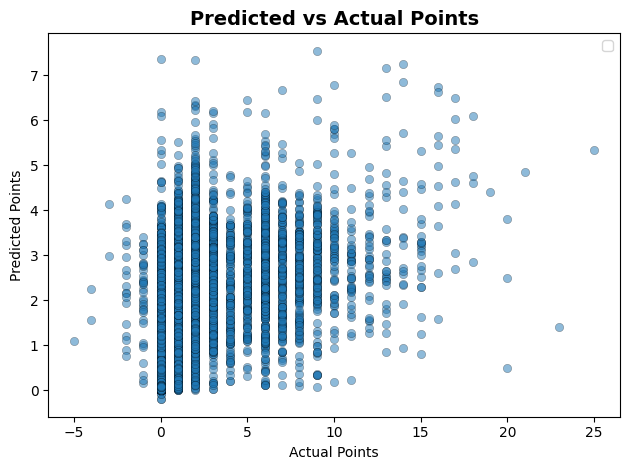

In [65]:
all_season_gws_df = all_season_gws_df.sort_values(['name', 'season', 'kickoff_time'])
train_df = all_season_gws_df[all_season_gws_df['season'] < '2024-25']
test_df = all_season_gws_df[all_season_gws_df['season'] == '2024-25']

WINDOW_FOR_VALIDATION = 5

FEATURE_COLUMNS = [
    'position',
    'value_above_position_floor',
    'was_home',
    'transfers_balance',
    'points_per_90_before_gw',
    'avg_minutes_last_{}_games'.format(WINDOW_FOR_VALIDATION),
    'consecutive_zero_gws_before',
    'definite_suspension',
    'opp_team_goals_conceded_rolling{}'.format(WINDOW_FOR_VALIDATION),
    'opp_team_goals_scored_rolling{}'.format(WINDOW_FOR_VALIDATION),
    'own_team_goals_conceded_rolling{}'.format(WINDOW_FOR_VALIDATION),
    'own_team_goals_scored_rolling{}'.format(WINDOW_FOR_VALIDATION),
    'avg_points_last_{}_games'.format(WINDOW_FOR_VALIDATION),
    'threat_avg_last_{}_games'.format(WINDOW_FOR_VALIDATION),
    'creativity_avg_last_{}_games'.format(WINDOW_FOR_VALIDATION),
    'influence_avg_last_{}_games'.format(WINDOW_FOR_VALIDATION),
    'minutes_last_gw',
    'starts_last3',
    'minutes_std_last5',
    'bps_avg_last_{}_games'.format(WINDOW_FOR_VALIDATION),
]

TARGET_COLUMN = 'total_points'
VAL_SEASON = '2023-24' 

train_df = all_season_gws_df[(all_season_gws_df['season'] < '2024-25') & (all_season_gws_df['season'] != VAL_SEASON)]
val_df = all_season_gws_df[all_season_gws_df['season'] == VAL_SEASON]
test_df = all_season_gws_df[all_season_gws_df['season'] == '2024-25']

X_train, y_train = train_df[FEATURE_COLUMNS], train_df[TARGET_COLUMN]
X_val, y_val = val_df[FEATURE_COLUMNS], val_df[TARGET_COLUMN]
X_test, y_test = test_df[FEATURE_COLUMNS], test_df[TARGET_COLUMN]

model = lgb.LGBMRegressor(
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='mae',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
)

y_pred = model.predict(X_test)
test_df['predicted_points'] = y_pred

plt.scatter(y_test, y_pred, alpha=0.5, edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.xlabel('Actual Points')
plt.ylabel('Predicted Points')
plt.title('Predicted vs Actual Points', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)
spearman_all, _ = spearmanr(y_test, y_pred)
print(f"\nMAE (all players): {test_mae:.3f}")
print(f"R² (all players): {test_r2:.3f}")
print(f"Spearman rank corr (all players): {spearman_all:.3f}")

# 2. Filter out the "deadwood" (players who played 0 minutes in the target week)
# We only want to evaluate how well the model predicts points for players who actually play
active_players_df = test_df[test_df['minutes'] > 0] 
true_mae = mean_absolute_error(active_players_df['total_points'], active_players_df['predicted_points'])
true_r2 = r2_score(active_players_df['total_points'], active_players_df['predicted_points'])
spearman_playing, _ = spearmanr(active_players_df['total_points'], active_players_df['predicted_points'])
print(f"\nMAE (played only): {true_mae:.3f}")
print(f"R² (played only): {true_r2:.3f}")
print(f"Spearman rank corr (played only): {spearman_playing:.3f}")


MAE (all players): 1.051
R² (all players): 0.307
Spearman rank corr (all players): 0.708

MAE (played only): 1.845
R² (played only): 0.061
Spearman rank corr (played only): 0.355


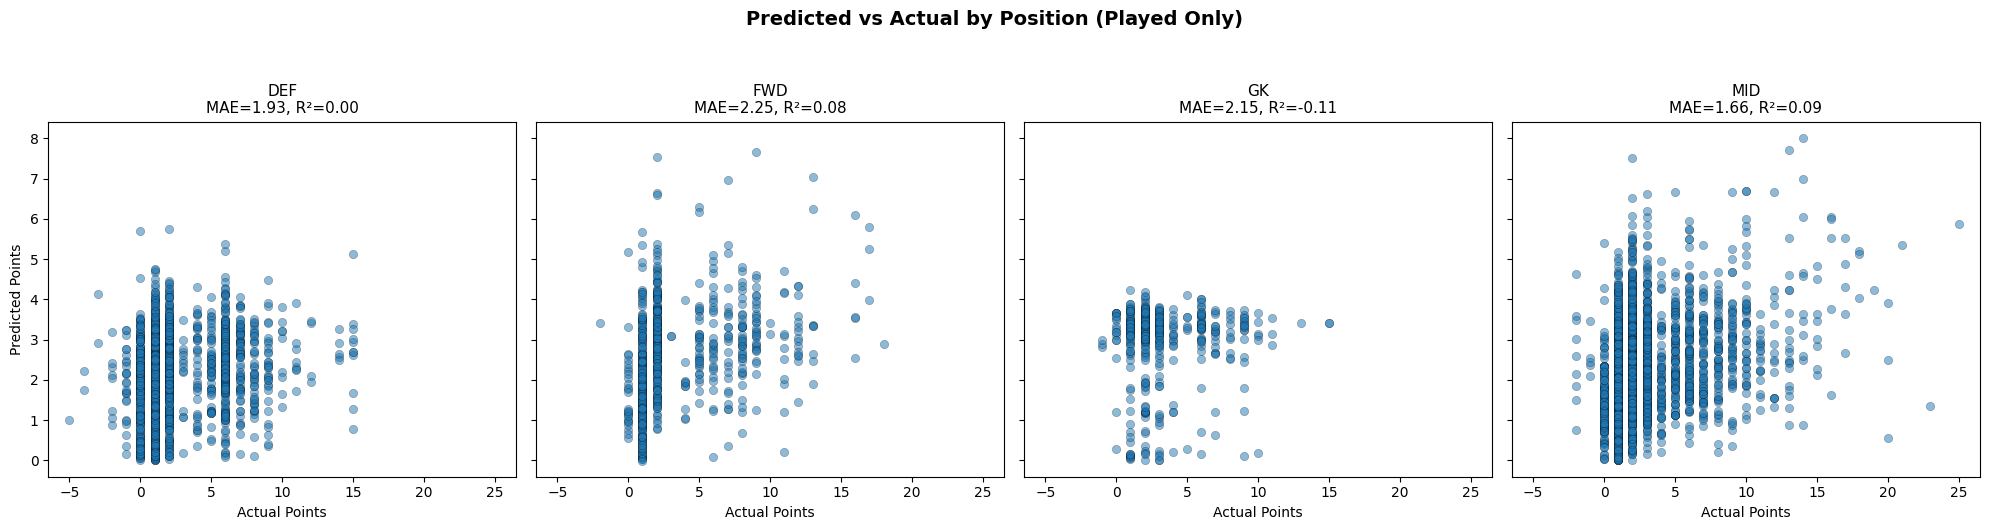

In [62]:
positions = active_players_df['position'].unique()
n = len(positions)

fig, axes = plt.subplots(1, n, figsize=(5*n, 5), sharex=True, sharey=True)

for ax, pos in zip(axes, sorted(positions)):
    sub = active_players_df[active_players_df['position'] == pos]
    ax.scatter(sub['total_points'], sub['predicted_points'], alpha=0.5, edgecolor='k', linewidth=0.3)
    
    lims = [active_players_df['total_points'].min(), active_players_df['total_points'].max()]
    
    mae = mean_absolute_error(sub['total_points'], sub['predicted_points'])
    r2 = r2_score(sub['total_points'], sub['predicted_points'])
    
    ax.set_title(f'{pos}\nMAE={mae:.2f}, R²={r2:.2f}', fontsize=11)
    ax.set_xlabel('Actual Points')

axes[0].set_ylabel('Predicted Points')
plt.suptitle('Predicted vs Actual by Position (Played Only)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

## Supporting material

Scoring table:

| Action                                                      | Points |
|-------------------------------------------------------------|--------|
| For playing up to 60 minutes                                | 1      |
| For playing 60 minutes or more (excluding   stoppage time)  | 2      |
| For each goal scored by a goalkeeper                        | 10     |
| For each goal scored by a defender                          | 6      |
| For each goal scored by a midfielder                        | 5      |
| For each goal scored by a forward                           | 4      |
| For each assist for a goal                                  | 3      |
| For a clean sheet by a goalkeeper or   defender             | 4      |
| For a clean sheet by a midfielder                           | 1      |
| For every 3 shots saved by a   goalkeeper                   | 1      |
| For each penalty save                                       | 5      |
| For each penalty miss                                       | -2     |
| Bonus points for the best players in a   match              | 01-Mar |
| For every 2 goals conceded by a goalkeeper   or defender    | -1     |
| For each yellow card                                        | -1     |
| For each red card                                           | -3     |
| For each own goal                                           | -2     |